In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 中英文兼容

In [11]:
def plot_confusion_matrix(tp, tn, fp, fn, class_names=['Negative', 'Positive']):
    """
    绘制包含丰富信息的2x2混淆矩阵
    参数:
        tp: True Positive
        tn: True Negative
        fp: False Positive
        fn: False Negative
        class_names: 类别名称列表 [负类, 正类]
    """
    # 构建混淆矩阵
    cm = np.array([[tn, fp],
                   [fn, tp]])
    
    # 计算总体样本数
    total = tn + fp + fn + tp
    
    # 计算各项指标
    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # 注释文本：数字 + 百分比
    annotations = [[f"{cm[i][j]}\n({cm[i][j]/total:.2%})" for j in range(2)] for i in range(2)]

    # 颜色映射
    cmap = sns.color_palette("Blues", as_cmap=True)

    # 绘制热力图
    plt.figure(figsize=(3.5, 3.5))
    sns.heatmap(cm, annot=np.array(annotations), fmt='', cmap=cmap,
                annot_kws={"size": 13}, cbar=False,
                xticklabels=class_names, yticklabels=class_names)

    # 添加标题与指标
    # title = (
    #     f"Accuracy: {accuracy:.2%}\n"
    #     f"Precision: {precision:.2%}\n"
    #     f"Recall: {recall:.2%}\n"
    #     f"F1 Score: {f1_score:.2%}"
    # )
    # plt.title(title, fontsize=12, pad=20)
    plt.xlabel('Predicted', fontsize=13)
    plt.ylabel('Ground truth', fontsize=13)
    plt.xticks(rotation=0, fontsize=13)
    plt.yticks(rotation=90, fontsize=13)
    plt.tight_layout()
    # plt.show()
    plt.savefig("confusion_matrix.pdf", format="pdf", dpi=300, bbox_inches='tight')

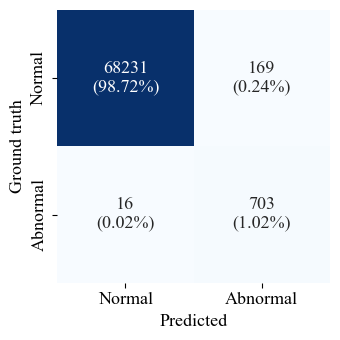

In [12]:
tp = 703
tn = 68231
fp = 169
fn = 16
class_names = ['Normal', 'Abnormal']

plot_confusion_matrix(tp, tn, fp, fn, class_names)